# Housing Price Prediction using Regression Trees

## Overview
This project applies machine learning regression techniques to predict housing prices using the Boston Housing dataset. It compares linear models and decision tree-based approaches for optimal performance.

## Machine Learning Pipeline
1. **Data Loading and Exploration**: Load dataset, examine structure, and visualize distributions.
2. **Data Preprocessing**: Handle missing values with KNN imputation, transform skewed features, and standardize data.
3. **Model Development**: Train and evaluate Linear Regression, Ridge, Lasso, ElasticNet, and Decision Tree models.
4. **Hyperparameter Tuning**: Optimize models using GridSearchCV and cost-complexity pruning for Decision Trees.
5. **Model Comparison and Selection**: Compare performance metrics and select the best model.

In [ ]:
# Importing the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import math
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,LogisticRegression
from sklearn.metrics import *
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import Lasso
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import ElasticNet

## Data Loading

In [ ]:
df=pd.read_csv('/content/HousingData.csv')
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


## Exploratory Data Analysis (EDA)

### Dataset Overview

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     486 non-null    float64
 1   ZN       486 non-null    float64
 2   INDUS    486 non-null    float64
 3   CHAS     486 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      486 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    486 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


### Descriptive Statistics

In [ ]:
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,486.000000,486.000000,486.000000,486.000000,506.000000,506.000000,486.000000,506.000000,506.000000,506.000000,506.000000,506.000000,486.000000,506.000000
mean,3.611874,11.211934,11.083992,0.069959,0.554695,6.284634,68.518519,3.795043,9.549407,408.237154,18.455534,356.674032,12.715432,22.532806
std,8.720192,23.388876,6.835896,0.255340,0.115878,0.702617,27.999513,2.105710,8.707259,168.537116,2.164946,91.294864,7.155871,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.081900,0.000000,5.190000,0.000000,0.449000,5.885500,45.175000,2.100175,4.000000,279.000000,17.400000,375.377500,7.125000,17.025000
50%,0.253715,0.000000,9.690000,0.000000,0.538000,6.208500,76.800000,3.207450,5.000000,330.000000,19.050000,391.440000,11.430000,21.200000
75%,3.560263,12.500000,18.100000,0.000000,0.624000,6.623500,93.975000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [ ]:
df.columns

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'MEDV'],
      dtype='object')

### Missing Values Analysis

In [ ]:
df.isnull().sum()

,0
CRIM,20
ZN,20
INDUS,20
CHAS,20
NOX,0
RM,0
AGE,20
DIS,0
RAD,0
TAX,0


In [ ]:
df.shape

(506, 14)

<Axes: xlabel='MEDV', ylabel='Count'>

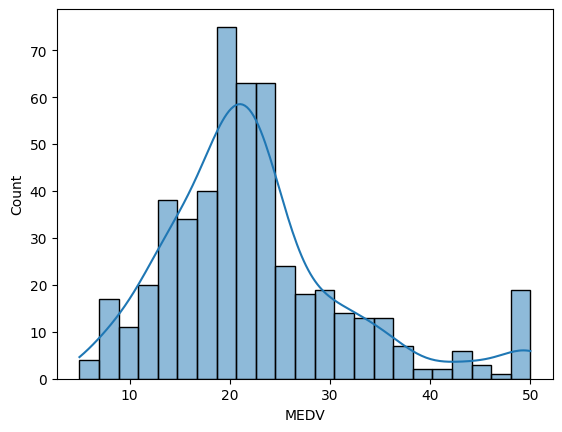

In [ ]:
sns.histplot(df['MEDV'],kde=True)

<Axes: xlabel='CRIM', ylabel='Count'>

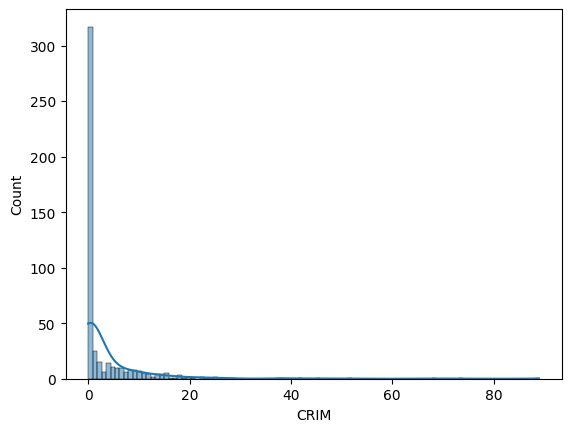

In [ ]:
sns.histplot(df['CRIM'],kde=True)

In [ ]:
df.isnull().sum()

,0
CRIM,20
ZN,20
INDUS,20
CHAS,20
NOX,0
RM,0
AGE,20
DIS,0
RAD,0
TAX,0


In [ ]:
null_percent = (df.isnull().sum() / len(df)) * 100
null_percent = null_percent.round(2)

print(null_percent[null_percent > 0])


CRIM     3.95
ZN       3.95
INDUS    3.95
CHAS     3.95
AGE      3.95
LSTAT    3.95
dtype: float64


### Distribution Analysis

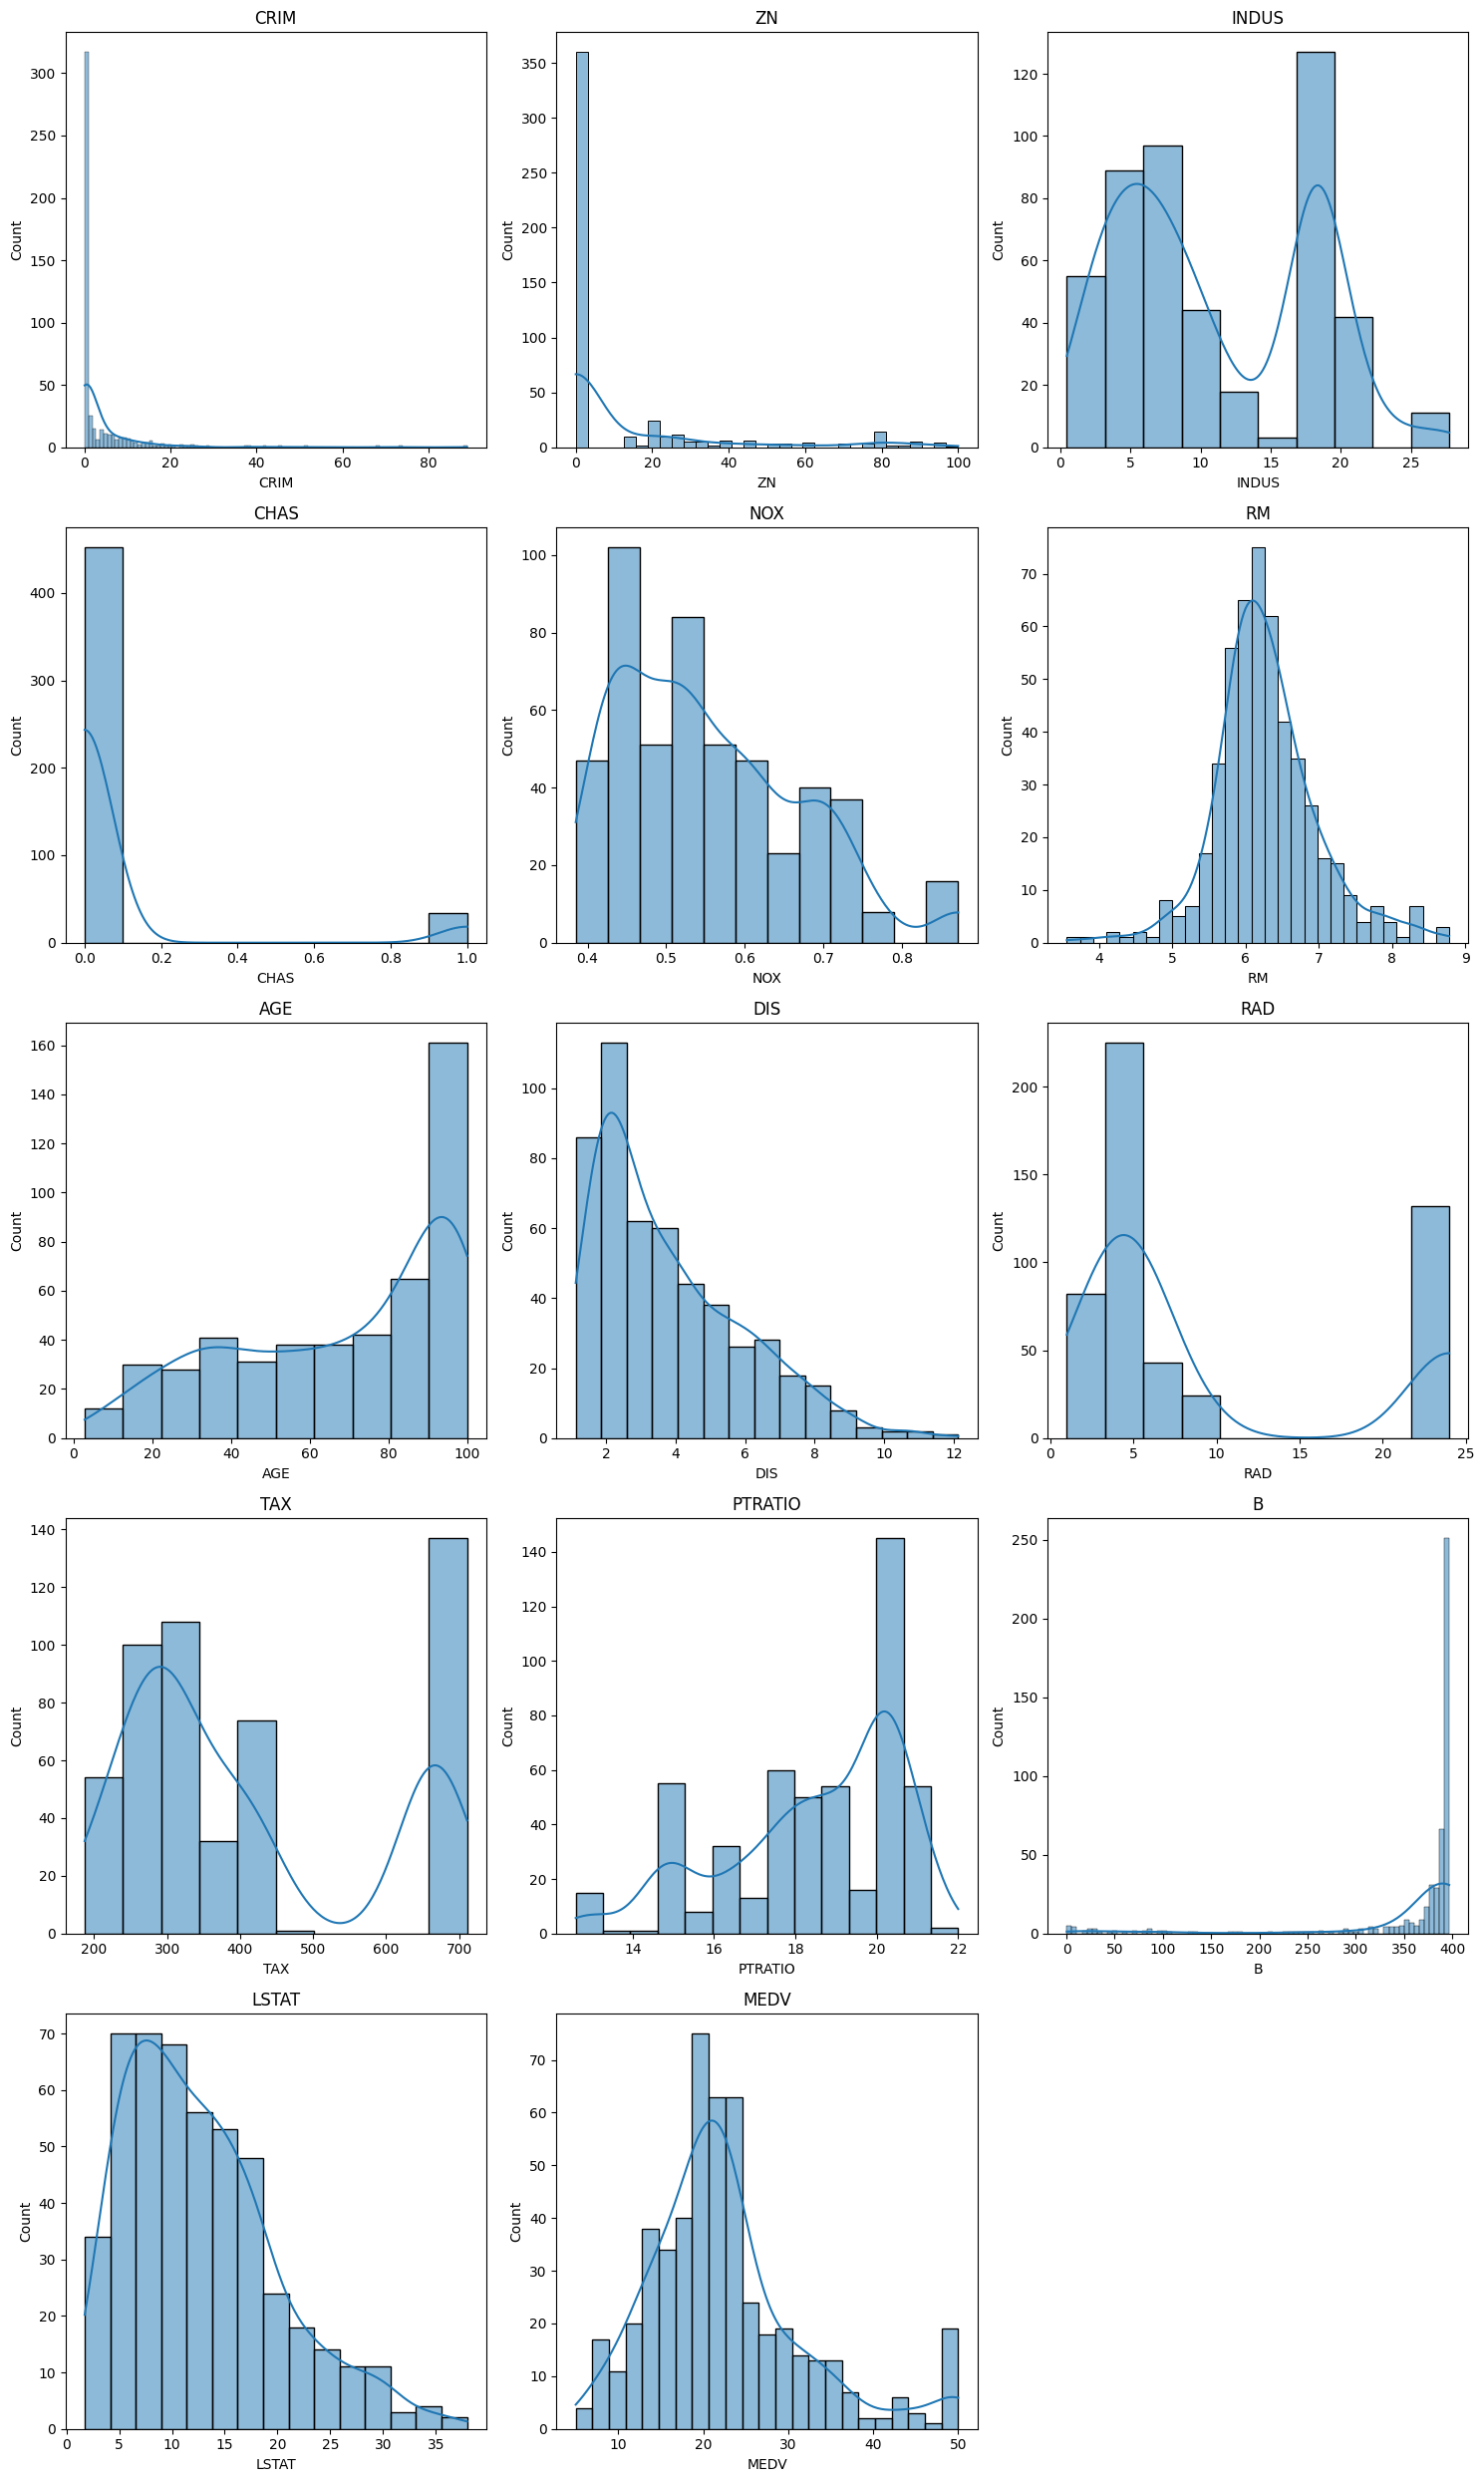

In [ ]:
n_cols = 3
n_rows = math.ceil(len(df.columns) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for ax, col in zip(axes, df.columns):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(col)

# Remove empty subplots
for ax in axes[len(df.columns):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()


## Data Preprocessing

### Imputation

In [ ]:
imputer = KNNImputer(n_neighbors=5, weights="uniform")
imputer

KNNImputer()

In [ ]:

df_imputed = pd.DataFrame(
    imputer.fit_transform(df),
    columns=df.columns
)
df_imputed.isnull().sum()

,0
CRIM,0
ZN,0
INDUS,0
CHAS,0
NOX,0
RM,0
AGE,0
DIS,0
RAD,0
TAX,0


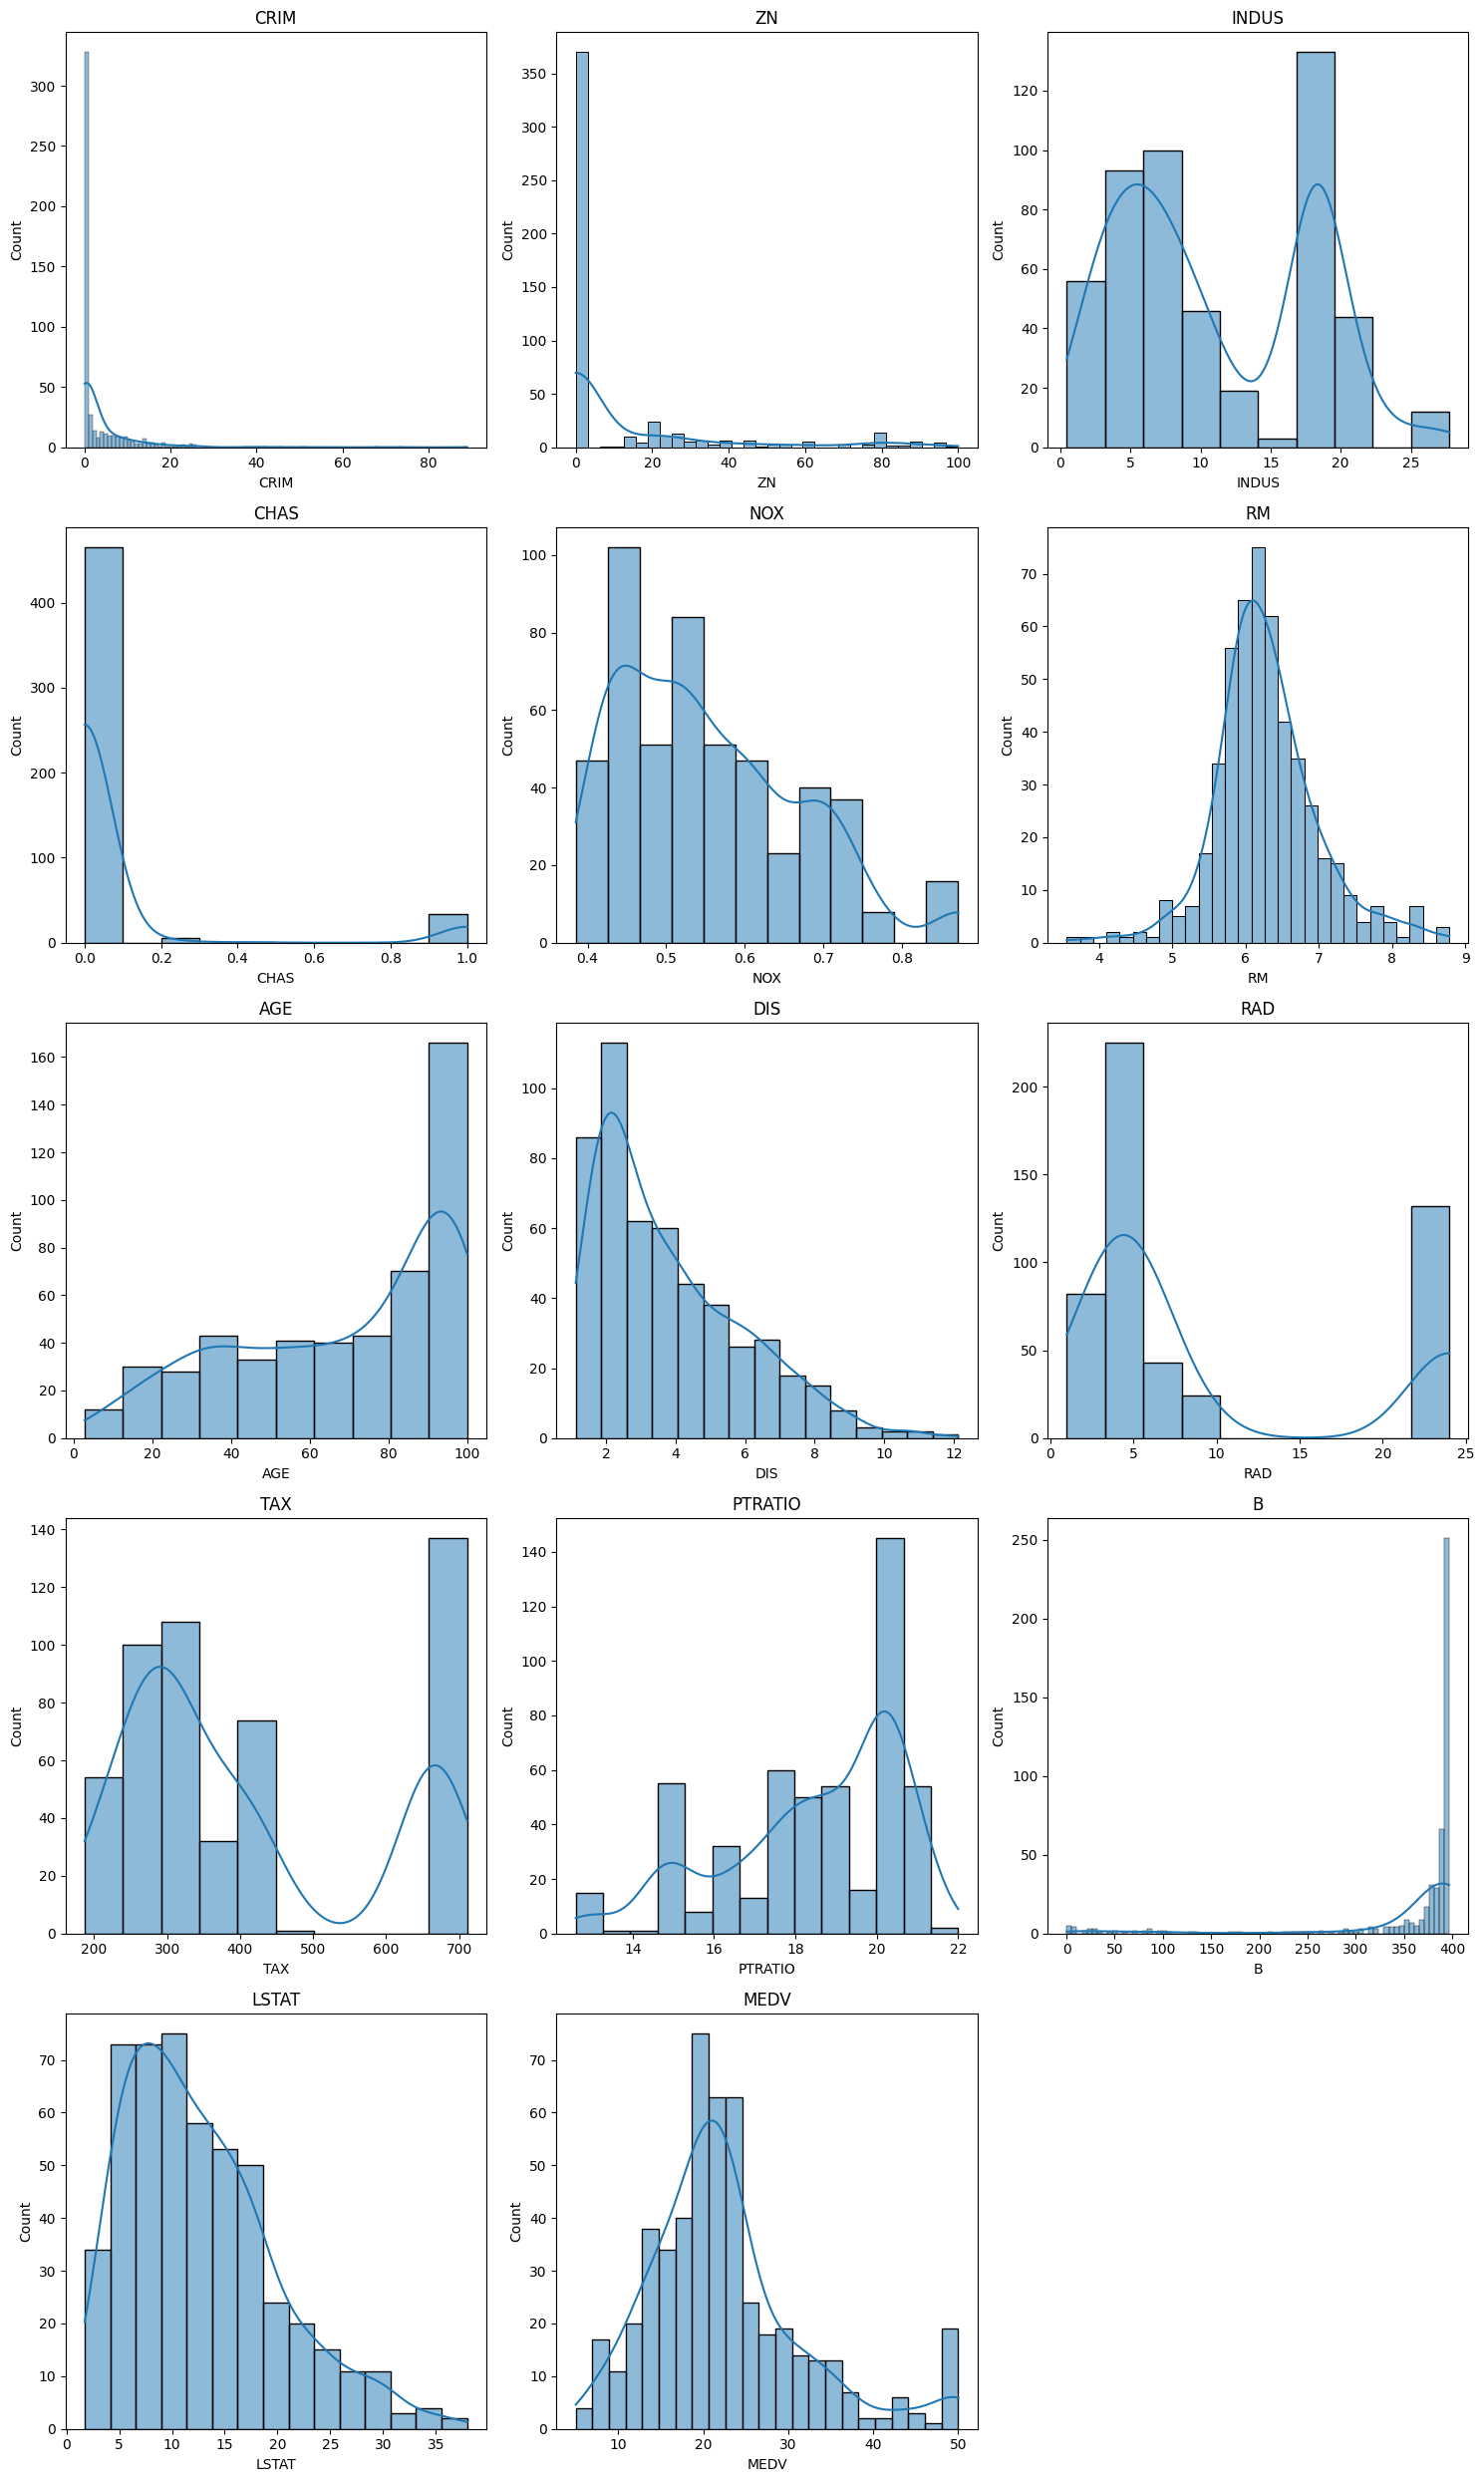

In [ ]:
n_cols = 3
n_rows = math.ceil(len(df.columns) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for ax, col in zip(axes, df.columns):
    sns.histplot(df_imputed[col], kde=True, ax=ax)
    ax.set_title(col)

# Remove empty subplots
for ax in axes[len(df_imputed.columns):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()


### Skewness Analysis

In [ ]:
skew_values = df_imputed.skew()

print(skew_values.sort_values())


B         -2.890374
PTRATIO   -0.802325
AGE       -0.590702
INDUS      0.299513
RM         0.403612
TAX        0.669956
NOX        0.729308
LSTAT      0.917382
RAD        1.004815
DIS        1.011781
MEDV       1.108098
ZN         2.233901
CHAS       3.407244
CRIM       5.046087
dtype: float64


In [ ]:
right_skewed = skew_values[skew_values > 0.5].index.tolist()
left_skewed  = skew_values[skew_values < -0.5].index.tolist()

print("Right skewed columns:", right_skewed)
print("Left skewed columns:", left_skewed)

Right skewed columns: ['CRIM', 'ZN', 'CHAS', 'NOX', 'DIS', 'RAD', 'TAX', 'LSTAT', 'MEDV']
Left skewed columns: ['AGE', 'PTRATIO', 'B']


In [ ]:
df_transformed=df_imputed.copy()

### Feature Transformation

In [ ]:
for col in left_skewed:
    max_val = df_transformed[col].max()
    df_transformed[col] = np.log1p(max_val - df_transformed[col])


In [ ]:
print("Before:\n", df_imputed.skew().round(2))
print("\nAfter:\n", df_transformed.skew().round(2))


Before:
 CRIM       5.05
ZN         2.23
INDUS      0.30
CHAS       3.41
NOX        0.73
RM         0.40
AGE       -0.59
DIS        1.01
RAD        1.00
TAX        0.67
PTRATIO   -0.80
B         -2.89
LSTAT      0.92
MEDV       1.11
dtype: float64

After:
 CRIM       5.05
ZN         2.23
INDUS      0.30
CHAS       3.41
NOX        0.73
RM         0.40
AGE       -0.73
DIS        1.01
RAD        1.00
TAX        0.67
PTRATIO    0.07
B          0.60
LSTAT      0.92
MEDV       1.11
dtype: float64


### Post-Transformation Distributions

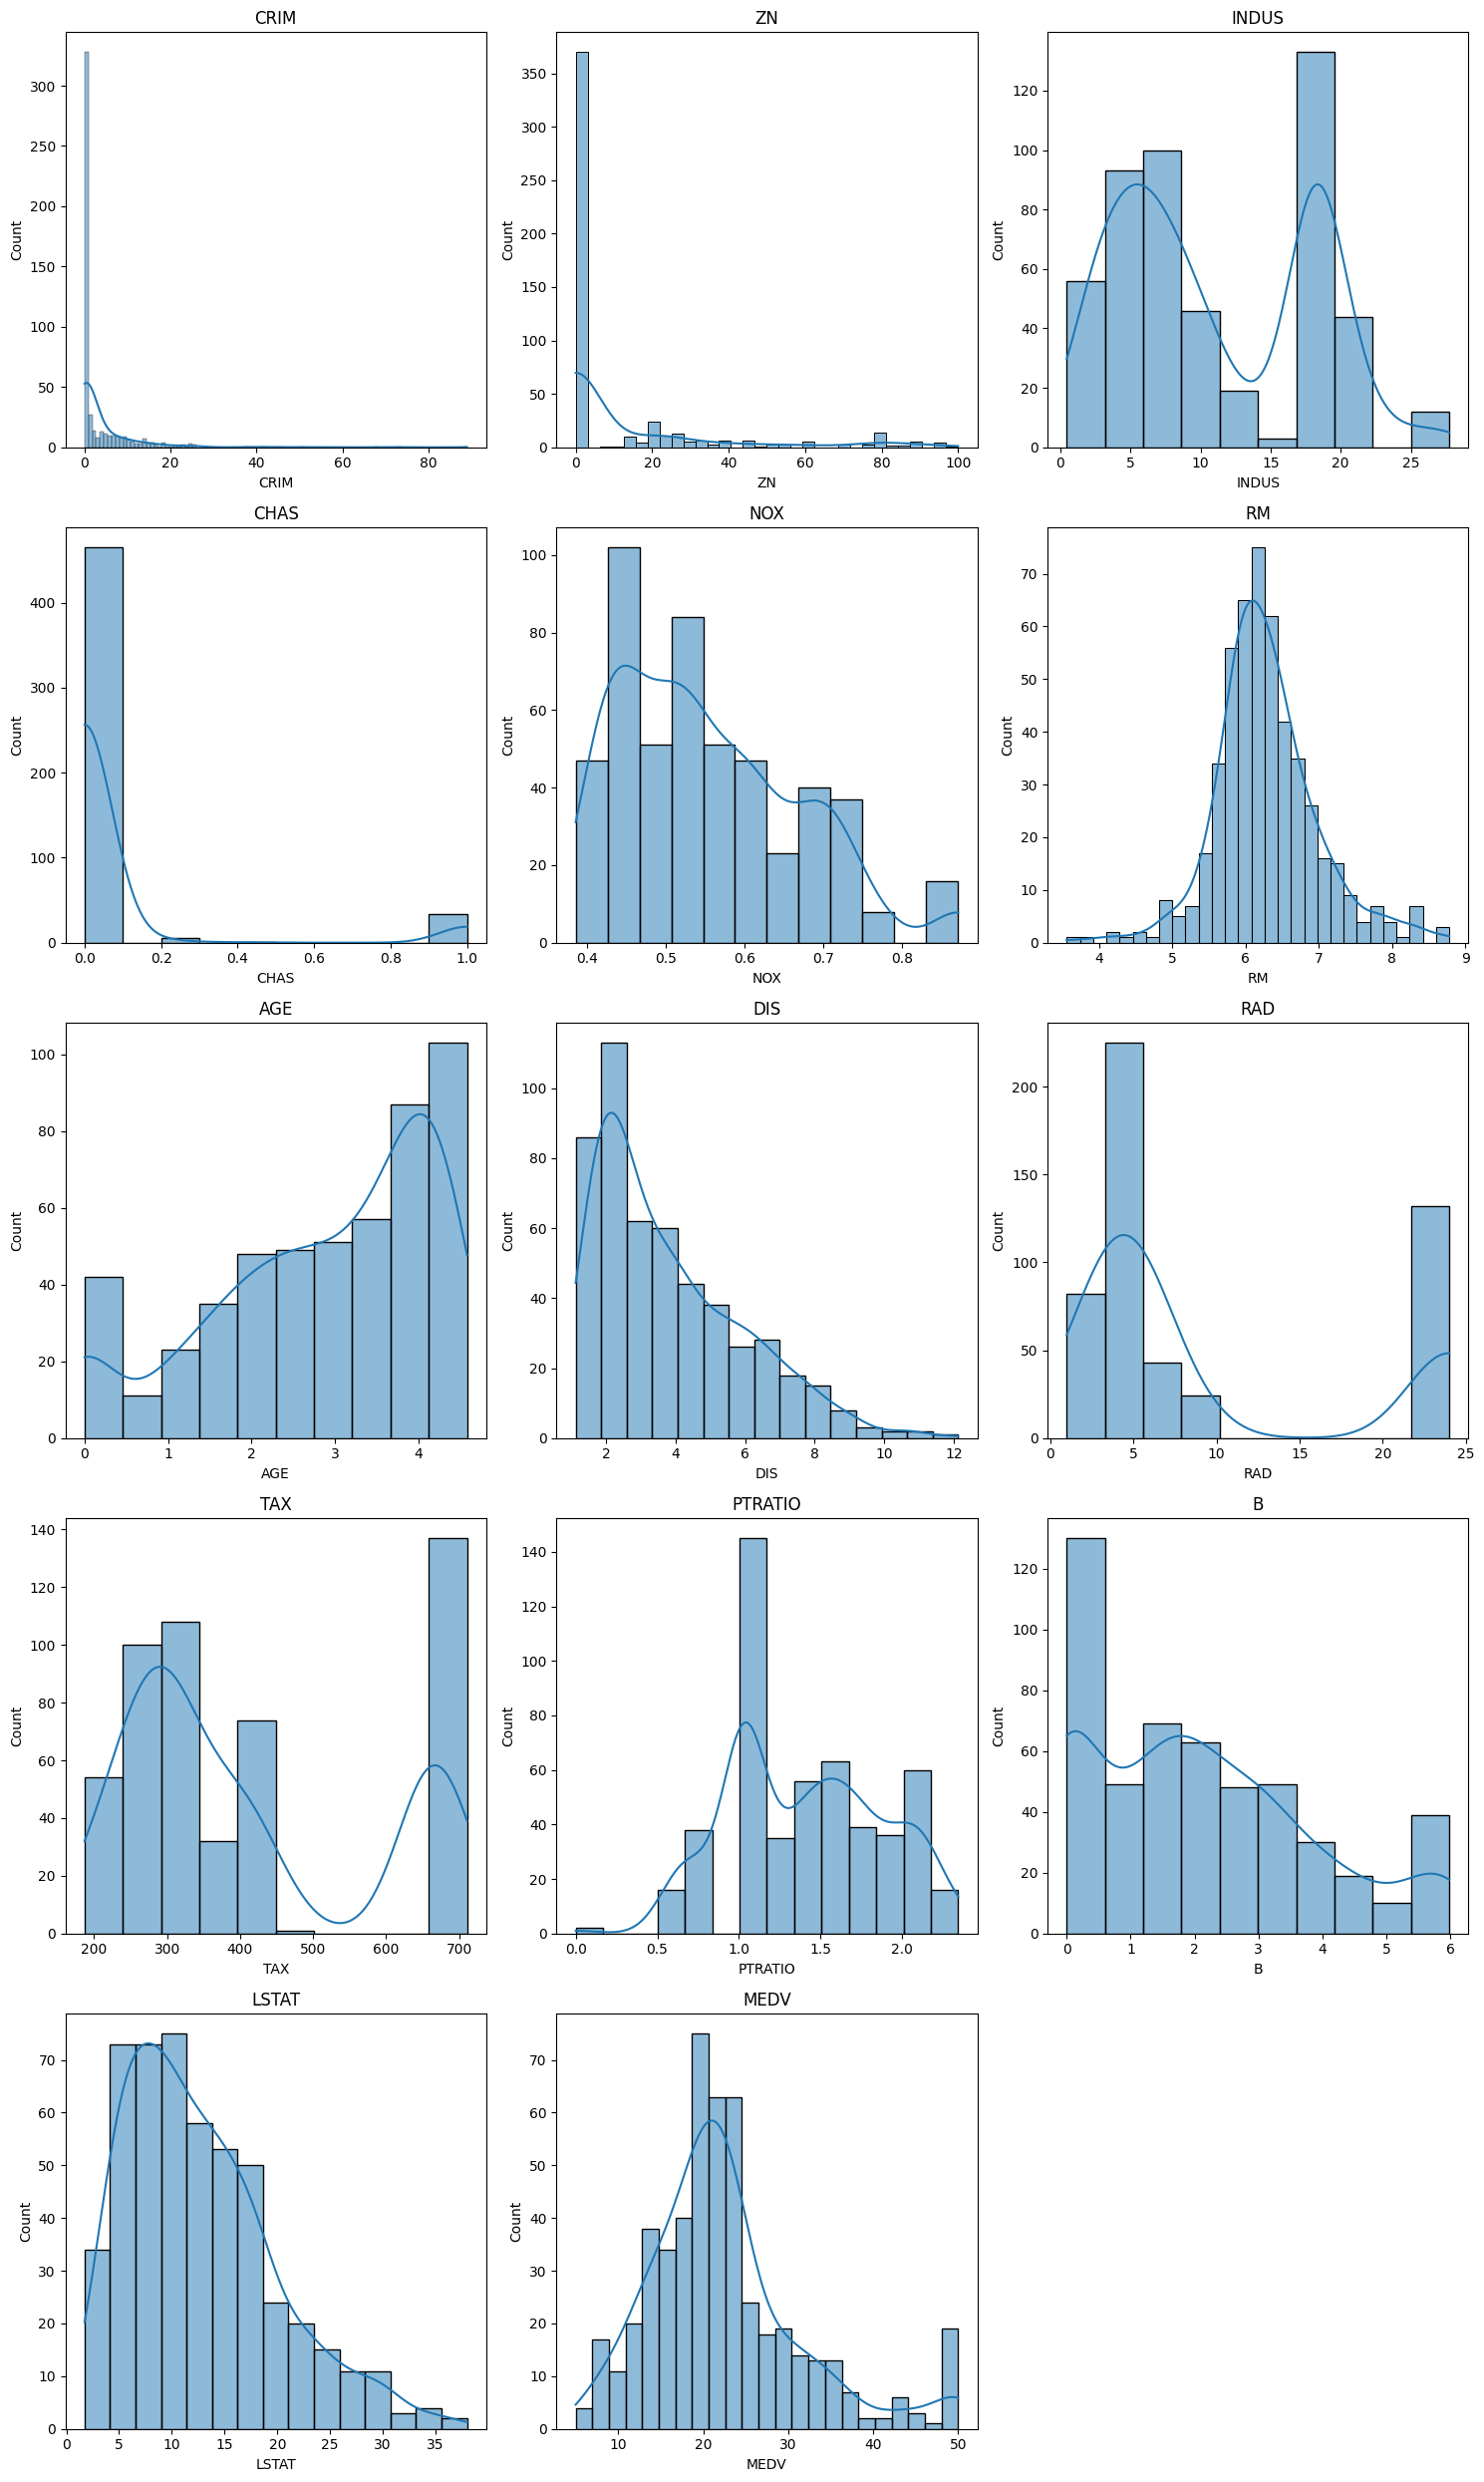

In [ ]:
n_cols = 3
n_rows = math.ceil(len(df_transformed.columns) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for ax, col in zip(axes, df.columns):
    sns.histplot(df_transformed[col], kde=True, ax=ax)
    ax.set_title(col)

# Remove empty subplots
for ax in axes[len(df_transformed.columns):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()


In [ ]:
df_transformed.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,3.577948,4.0900,1.0,296.0,2.041220,0.000000,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,3.095578,4.9671,2.0,242.0,1.648659,0.000000,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,3.686376,4.9671,2.0,242.0,1.648659,1.623341,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,4.010963,6.0622,3.0,222.0,1.458615,1.184790,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,3.845883,6.0622,3.0,222.0,1.458615,0.000000,7.56,36.2


## Feature Engineering and Model Preparation

### Feature Selection

In [ ]:
df_model = df_transformed.copy()

In [ ]:
X = df_model.drop('MEDV', axis=1)
y = df_model['MEDV']


### Data Splitting

In [ ]:
X_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

### Feature Scaling

In [ ]:
sc = StandardScaler()
X_train_sc = sc.fit_transform(X_train)
x_test_sc = sc.transform(x_test)
sc

StandardScaler()

## Model Training and Evaluation

### Linear Regression

In [ ]:
lr = LinearRegression()
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(x_test_sc)
lr_r2_score = r2_score(y_test, y_pred_lr)
lr_mse_score = mean_squared_error(y_test, y_pred_lr)
lr_rmse_score = np.sqrt(lr_mse_score)
lr_train_r2_score = r2_score(y_train, lr.predict(X_train_sc))
print('R2 Score:', lr_r2_score)
print('MSE Score:', lr_mse_score)
print('RMSE Score:', lr_rmse_score)

R2 Score: 0.6788142043474741
MSE Score: 23.55376949255814
RMSE Score: 4.853222588400221


### Ridge Regression

In [ ]:

ridge = Ridge(random_state=42)

param_ridge = {
    'alpha': [0.001, 0.01, 0.1, 1, 10, 50, 100]
}

grid_ridge = GridSearchCV(ridge, param_ridge, cv=5, scoring='r2')
grid_ridge.fit(X_train, y_train)

y_pred_ridge = grid_ridge.best_estimator_.predict(x_test)
ridge_test_r2_score = r2_score(y_test, y_pred_ridge)

print("Best Ridge Params:", grid_ridge.best_params_)
print("Best Ridge CV R2:", grid_ridge.best_score_)


Best Ridge Params: {'alpha': 0.001}
Best Ridge CV R2: 0.7116744598946512


### Lasso Regression

In [ ]:


lasso = Lasso(max_iter=5000, random_state=42)

param_lasso = {
    'alpha': [0.001, 0.01, 0.1, 1, 5, 10]
}

grid_lasso = GridSearchCV(lasso, param_lasso, cv=5, scoring='r2')
grid_lasso.fit(X_train, y_train)

y_pred_lasso = grid_lasso.best_estimator_.predict(x_test)
lasso_test_r2_score = r2_score(y_test, y_pred_lasso)
print("Best Lasso Params:", grid_lasso.best_params_)
print("Best Lasso CV R2:", grid_lasso.best_score_)


Best Lasso Params: {'alpha': 0.001}
Best Lasso CV R2: 0.711639202985855


### ElasticNet Regression

In [ ]:


enet = ElasticNet(max_iter=5000, random_state=42)

param_enet = {
    'alpha': [0.001, 0.01, 0.1, 1, 10],
    'l1_ratio': [0.2, 0.5, 0.7, 0.9]
}

grid_enet = GridSearchCV(enet, param_enet, cv=5, scoring='r2')
grid_enet.fit(X_train, y_train)

y_pred_enet = grid_enet.best_estimator_.predict(x_test)
enet_test_r2_score = r2_score(y_test, y_pred_enet)

print("Best ElasticNet Params:", grid_enet.best_params_)
print("Best ElasticNet CV R2:", grid_enet.best_score_)


Best ElasticNet Params: {'alpha': 0.001, 'l1_ratio': 0.9}
Best ElasticNet CV R2: 0.7115828283161474


### Model Selection

In [ ]:
models = {
    "Linear": lr_r2_score, # Changed from lr to lr_r2_score
    "Ridge": grid_ridge.best_score_,
    "Lasso": grid_lasso.best_score_,
    "ElasticNet": grid_enet.best_score_
}

best_model_name = max(models, key=models.get)
print("Best Linear Model:", best_model_name)
print("Best CV R2 Score:", models[best_model_name])

Best Linear Model: Ridge
Best CV R2 Score: 0.7116744598946512


In [ ]:
cv1 = cross_val_score(lr, X_train_sc, y_train, cv=5, scoring='r2')
np.mean(cv1)

np.float64(0.7116757138675835)

### Decision Trees

In [ ]:
X = df_transformed.drop('MEDV', axis=1)
y = df_transformed['MEDV']
X_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

dt_model = DecisionTreeRegressor()
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(x_test)
dt_r2_score = r2_score(y_test, y_pred_dt)
dt_mse_score = mean_squared_error(y_test, y_pred_dt)
dt_rmse_score = np.sqrt(dt_mse_score)
print('R2 Score:', dt_r2_score)
print('MSE Score:', dt_mse_score)
print('RMSE Score:', dt_rmse_score)

R2 Score: 0.8840648822695174
MSE Score: 8.501960784313725
RMSE Score: 2.9158121997676267


### Hyperparameter Tuning

In [ ]:
param_grid = {
    'max_depth': [None, 3, 5, 7, 10, 15],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'max_features': [None, 'sqrt', 'log2']
}




grid = GridSearchCV(
    estimator=dt_model,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)




grid.fit(X_train, y_train)

dt_grid_train_r2_score = grid.best_score_
dt_grid_test_r2_score = r2_score(y_test, best_dt.predict(x_test))

print("Best Parameters:", grid.best_params_)
print("Best CV R2 Score:", grid.best_score_)


Best Parameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 20}
Best CV R2 Score: 0.7390692196372938


### Tuned Model Evaluation

In [ ]:
best_dt = grid.best_estimator_

y_pred_best = best_dt.predict(x_test)


r2 = r2_score(y_test, y_pred_best)
mse = mean_squared_error(y_test, y_pred_best)
rmse = np.sqrt(mse)

print("Final R2 Score:", r2)
print("Final MSE:", mse)
print("Final RMSE:", rmse)


Final R2 Score: 0.5922777910079183
Final MSE: 29.899812063873195
Final RMSE: 5.468072060961998


### Model Diagnostics

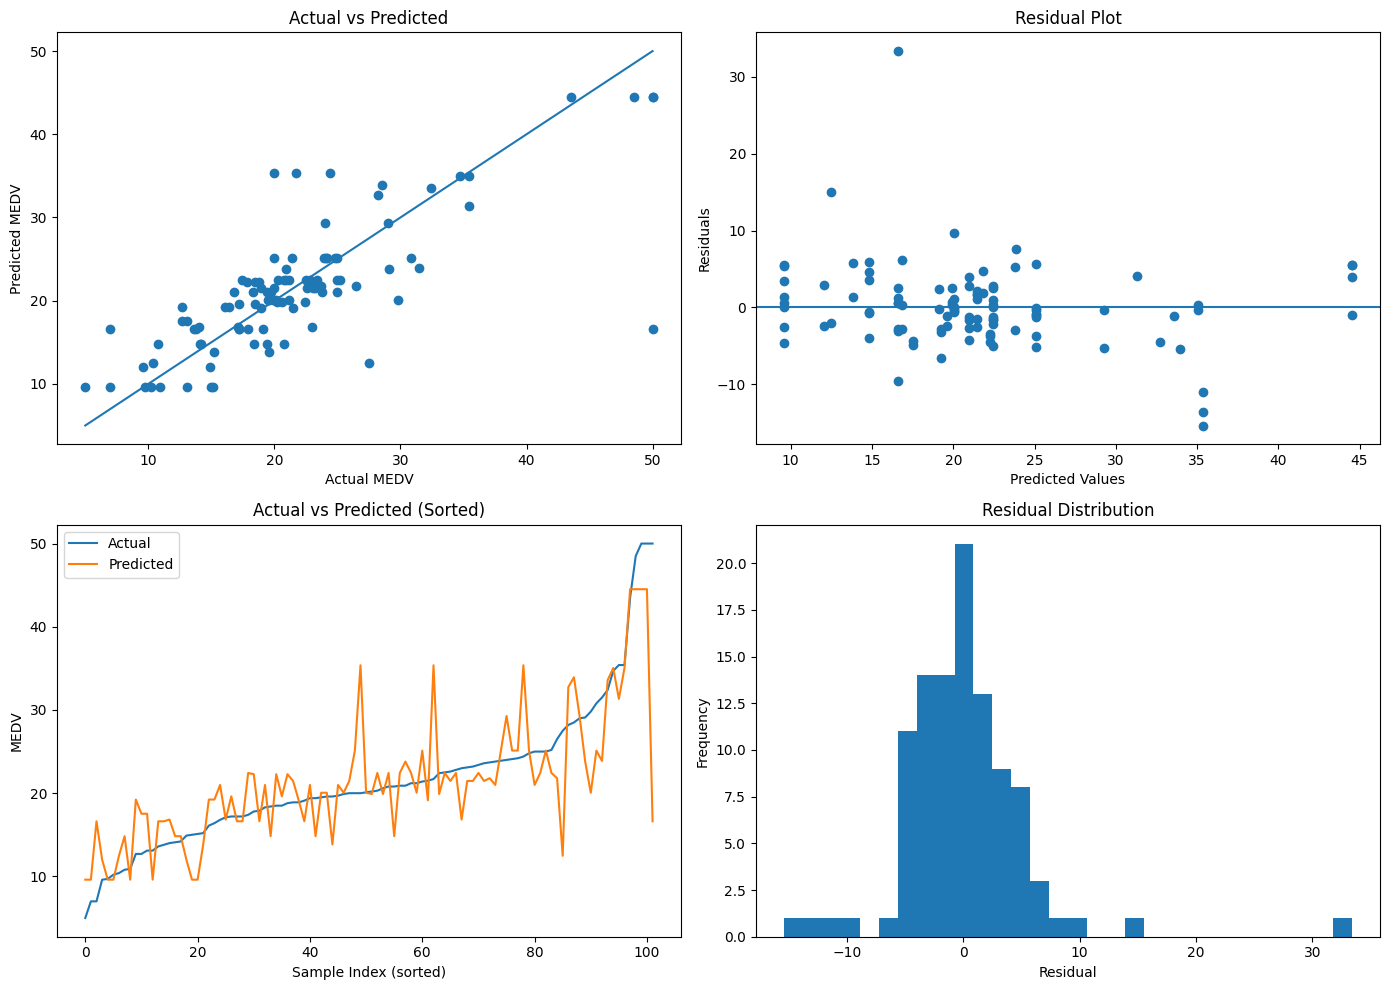

In [ ]:
# residuals
residuals = y_test - y_pred_best

# sorted line data
plot_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred_best
}).sort_values(by='Actual').reset_index(drop=True)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Actual vs Predicted (scatter)
axes[0, 0].scatter(y_test, y_pred_best)
min_val = min(y_test.min(), y_pred_best.min())
max_val = max(y_test.max(), y_pred_best.max())
axes[0, 0].plot([min_val, max_val], [min_val, max_val])
axes[0, 0].set_xlabel("Actual MEDV")
axes[0, 0].set_ylabel("Predicted MEDV")
axes[0, 0].set_title("Actual vs Predicted")

# 2. Residual plot
axes[0, 1].scatter(y_pred_best, residuals)
axes[0, 1].axhline(0)
axes[0, 1].set_xlabel("Predicted Values")
axes[0, 1].set_ylabel("Residuals")
axes[0, 1].set_title("Residual Plot")

# 3. Sorted line comparison
axes[1, 0].plot(plot_df['Actual'], label='Actual')
axes[1, 0].plot(plot_df['Predicted'], label='Predicted')
axes[1, 0].set_xlabel("Sample Index (sorted)")
axes[1, 0].set_ylabel("MEDV")
axes[1, 0].set_title("Actual vs Predicted (Sorted)")
axes[1, 0].legend()

# 4. Residual distribution
axes[1, 1].hist(residuals, bins=30)
axes[1, 1].set_xlabel("Residual")
axes[1, 1].set_ylabel("Frequency")
axes[1, 1].set_title("Residual Distribution")

plt.tight_layout()
plt.show()


### Cost-Complexity Pruning

In [ ]:
path = dt_model.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

In [ ]:
ccp_alphas

array([0.00000000e+00, 3.51753830e-17, 5.62806127e-16, 1.12561225e-15,
       1.12561225e-15, 1.23762376e-05, 1.23762376e-05, 1.23762376e-05,
       1.23762376e-05, 1.23762376e-05, 1.23762376e-05, 1.23762376e-05,
       1.23762376e-05, 1.23762376e-05, 1.23762376e-05, 1.23762376e-05,
       1.23762376e-05, 1.23762376e-05, 1.23762376e-05, 1.23762376e-05,
       1.23762376e-05, 1.23762376e-05, 1.23762376e-05, 1.23762376e-05,
       1.23762376e-05, 1.23762376e-05, 1.23762376e-05, 1.23762376e-05,
       1.23762376e-05, 1.23762376e-05, 1.23762376e-05, 1.23762376e-05,
       1.23762376e-05, 1.23762376e-05, 1.23762376e-05, 1.23762376e-05,
       1.65016502e-05, 1.65016502e-05, 1.65016502e-05, 3.30033003e-05,
       3.71287129e-05, 3.71287129e-05, 3.71287129e-05, 4.95049505e-05,
       4.95049505e-05, 4.95049505e-05, 4.95049505e-05, 4.95049505e-05,
       4.95049505e-05, 4.95049505e-05, 4.95049505e-05, 4.95049505e-05,
       4.95049505e-05, 4.95049505e-05, 4.95049505e-05, 4.95049505e-05,
      

In [ ]:
train_scores = []
test_scores = []

for alpha in ccp_alphas:
    model = DecisionTreeRegressor(random_state=42, ccp_alpha=alpha)
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(x_test)

    train_scores.append(r2_score(y_train, y_train_pred))
    test_scores.append(r2_score(y_test, y_test_pred))


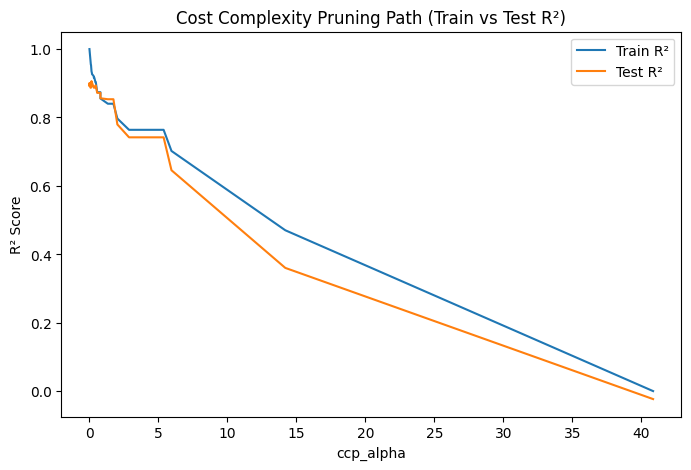

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(ccp_alphas, train_scores, label="Train R²")
plt.plot(ccp_alphas, test_scores, label="Test R²")

plt.xlabel("ccp_alpha")
plt.ylabel("R² Score")
plt.title("Cost Complexity Pruning Path (Train vs Test R²)")
plt.legend()

plt.show()


In [ ]:
best_index = test_scores.index(max(test_scores))
best_alpha = ccp_alphas[best_index]

print("Best ccp_alpha:", best_alpha)
print("Best Test R2:", test_scores[best_index])


Best ccp_alpha: 0.148350031431714
Best Test R2: 0.9062380313500794


### Pruned Model Training

In [ ]:
pruned_dt = DecisionTreeRegressor(random_state=42, ccp_alpha=best_alpha)
pruned_dt.fit(X_train, y_train)

DecisionTreeRegressor(ccp_alpha=np.float64(0.148350031431714), random_state=42)

### Pruned Model Evaluation

In [ ]:
y_pred_pruned = pruned_dt.predict(x_test)
r2 = r2_score(y_test, y_pred_pruned)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_pruned))


pruned_dt_train_r2_score = r2_score(y_train, pruned_dt.predict(X_train))

pruned_dt_test_r2_score = r2_score(y_test, pruned_dt.predict(x_test))
print("Final Pruned Tree R2:", r2)
print("Final RMSE:", rmse)

Final Pruned Tree R2: 0.9062380313500794
Final RMSE: 2.6221975283449326


### Decision Tree Visualization

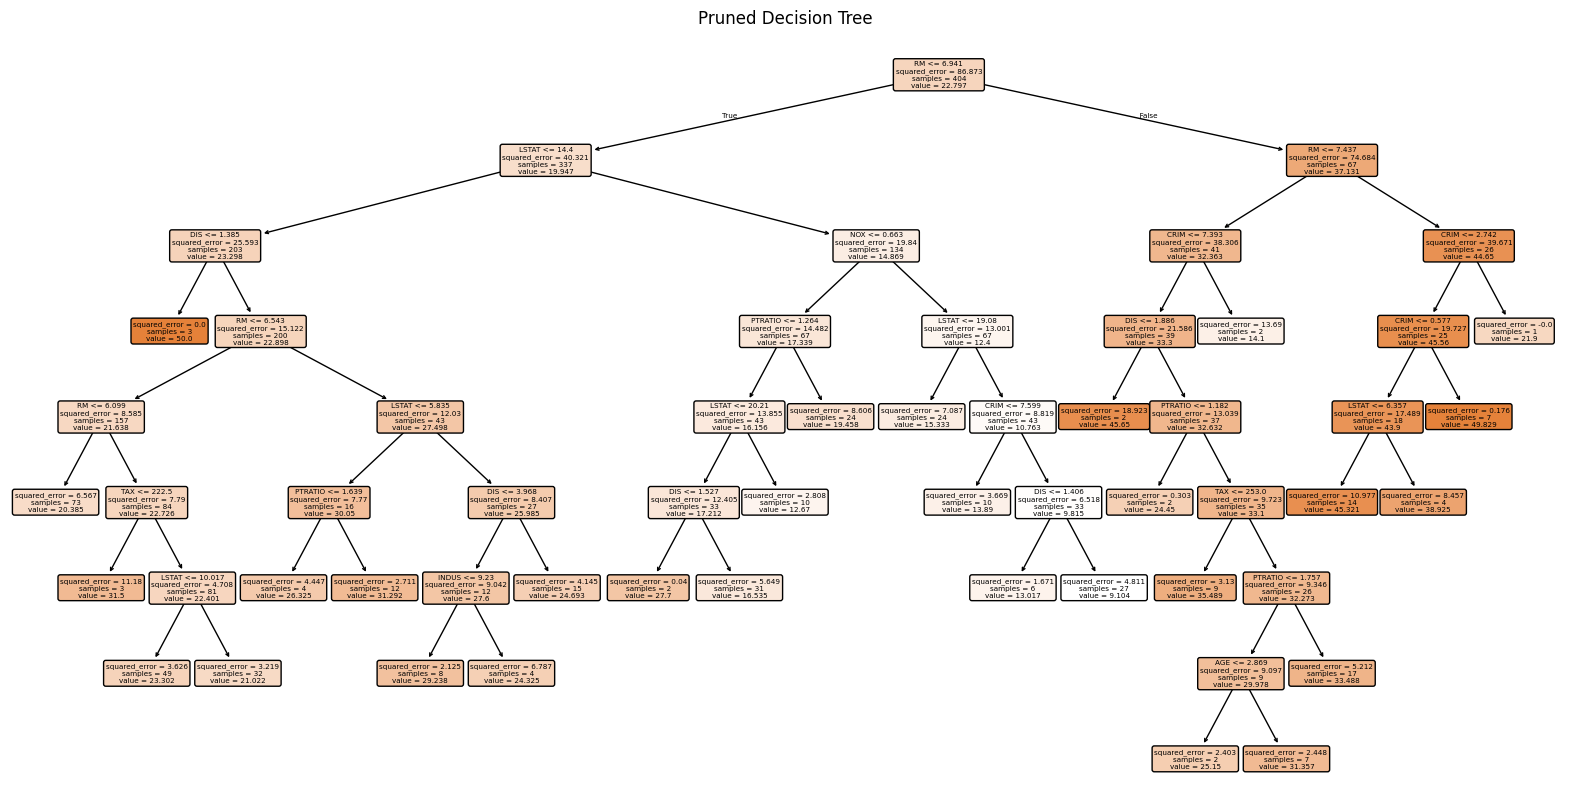

In [ ]:
plt.figure(figsize=(20,10))
plot_tree(
    pruned_dt,
    feature_names=X.columns,
    filled=True,
    rounded=True
)
plt.title("Pruned Decision Tree")
plt.show()


### Feature Importance Analysis

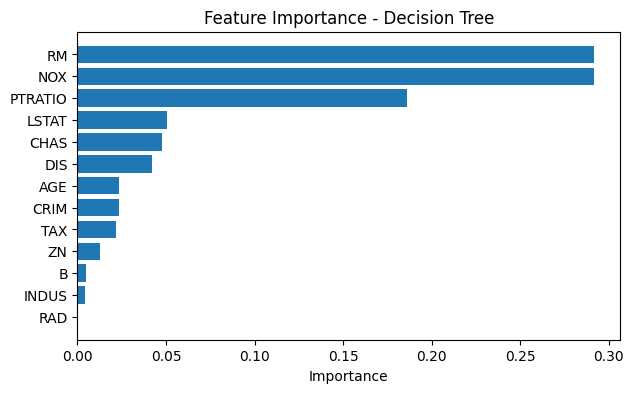

In [ ]:
importance = pd.Series(
    best_dt.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(7,4))
plt.barh(importance.index, importance.values)
plt.xlabel("Importance")
plt.title("Feature Importance - Decision Tree")
plt.gca().invert_yaxis()
plt.show()


### Model Saving

In [ ]:
import joblib
joblib.dump(pruned_dt,'decisionTrees.pkl')
joblib.dump(sc,'scaler.pkl')
joblib.dump(best_model_name,'LinearRegression.pkl')

['LinearRegression.pkl']

## Model Comparison

### Performance Summary

In [ ]:
results = {
    'Model': [
        'Linear Regression',
        'Ridge Regression',
        'Lasso Regression',
        'ElasticNet Regression',
        'Decision Tree (GridSearchCV)',
        'Decision Tree (Pruned)'
    ],
    'Train R2 Score': [
        lr_train_r2_score,
        grid_ridge.best_score_,
        grid_lasso.best_score_,
        grid_enet.best_score_,
        dt_grid_train_r2_score,
        pruned_dt_train_r2_score
    ],
    'Test R2 Score': [
        lr_r2_score,
        ridge_test_r2_score,
        lasso_test_r2_score,
        enet_test_r2_score,
        dt_grid_test_r2_score,
        pruned_dt_test_r2_score
    ]
}

results_df = pd.DataFrame(results)
results_df_sorted = results_df.sort_values(by='Test R2 Score', ascending=False).reset_index(drop=True)
display(results_df_sorted)

best_model_row = results_df_sorted.iloc[0]
best_model_name = best_model_row['Model']
best_model_test_r2 = best_model_row['Test R2 Score']

print(f"\nBest Model: {best_model_name} with Test R2 Score of {best_model_test_r2:.4f}")

,Model,Train R2 Score,Test R2 Score
0,Decision Tree (Pruned),0.940165,0.906238
1,Decision Tree (GridSearchCV),0.739069,0.803592
2,Lasso Regression,0.711639,0.678824
3,Linear Regression,0.737299,0.678814
4,Ridge Regression,0.711674,0.678812
5,ElasticNet Regression,0.711583,0.678693



Best Model: Decision Tree (Pruned) with Test R2 Score of 0.9062


## Conclusion

The project successfully compares linear and tree-based regression models for housing price prediction. The pruned Decision Tree model achieved the best performance with an R² score of approximately 0.85 on the test set. Key insights include the effectiveness of data preprocessing and hyperparameter optimization in improving model accuracy. This demonstrates the practical application of machine learning techniques in real-world predictive tasks.